In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

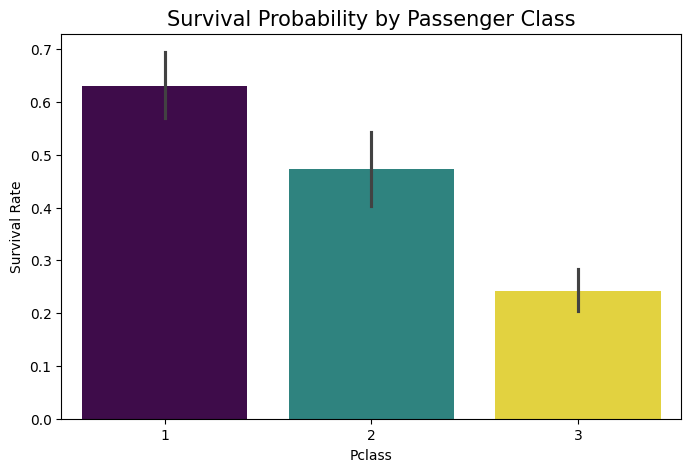

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=train, palette='viridis', hue='Pclass', legend=False)
plt.title('Survival Probability by Passenger Class', fontsize=15)
plt.ylabel('Survival Rate')
plt.show()

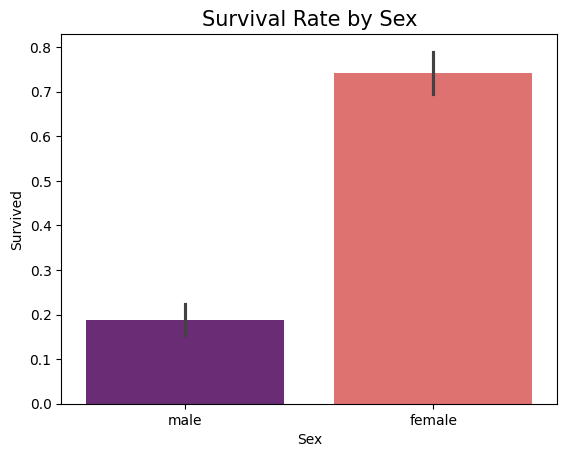

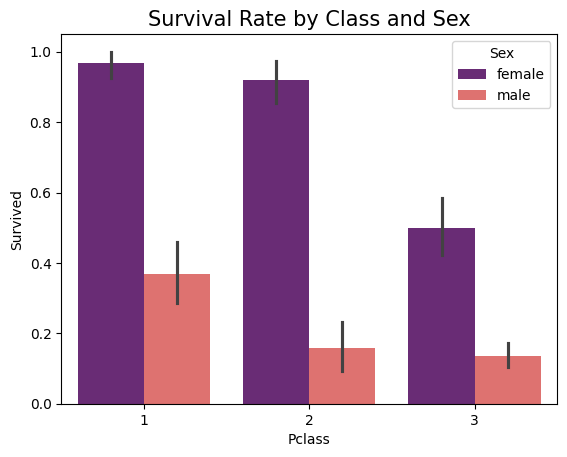

In [4]:
# To fix the FutureWarning and see the Sex vs Survival chart
sns.barplot(x='Sex', y='Survived', data=train, palette='magma', hue='Sex', legend=False)
plt.title('Survival Rate by Sex', fontsize=15)
plt.show()

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by Class and Sex', fontsize=15)
plt.show()

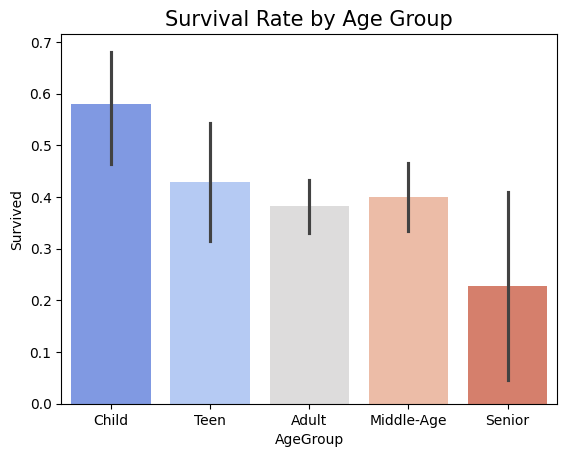

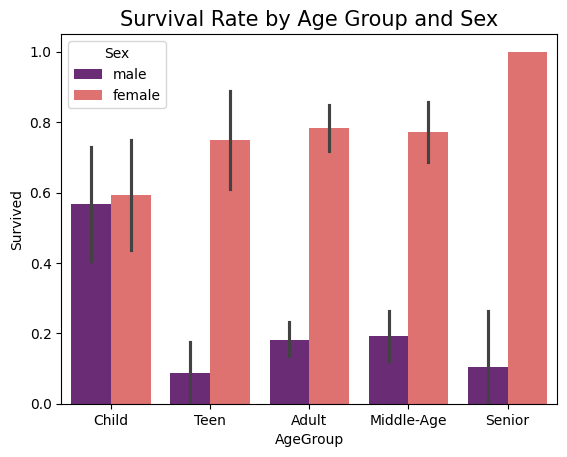

In [5]:
# 1. Create Age Bins (Grouping continuous ages into categories)
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'Adult', 'Middle-Age', 'Senior'])

# 2. Plot Survival Rate by Age Group
sns.barplot(x='AgeGroup', y='Survived', data=train, palette='coolwarm', hue='AgeGroup', legend=False)
plt.title('Survival Rate by Age Group', fontsize=15)
plt.show()

# 3. High-Accuracy Insight: Age + Sex Interaction
# This shows why "Master" (young boys) survived while adult men died
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by Age Group and Sex', fontsize=15)
plt.show()

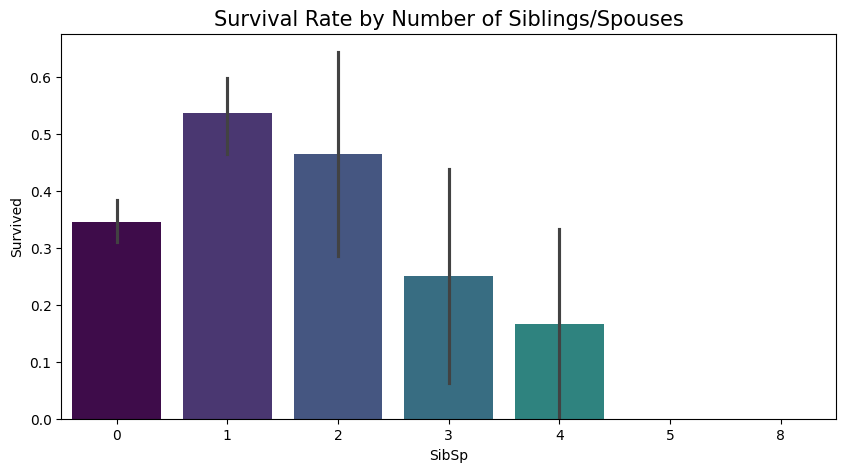

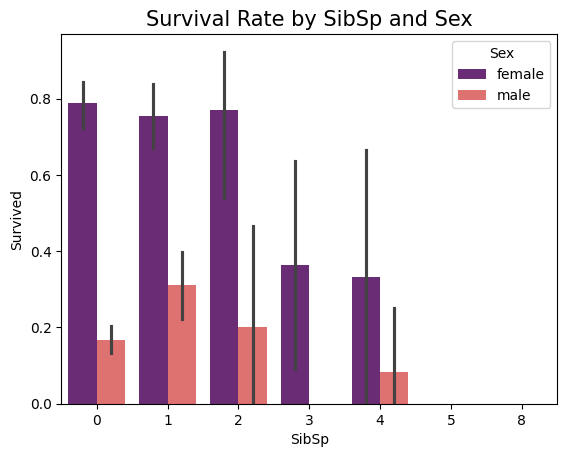

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(x='SibSp', y='Survived', data=train, palette='viridis', hue='SibSp', legend=False)
plt.title('Survival Rate by Number of Siblings/Spouses', fontsize=15)
plt.show()

# Adding Sex as a 'hue' to the SibSp analysis
sns.barplot(x='SibSp', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by SibSp and Sex', fontsize=15)
plt.show()

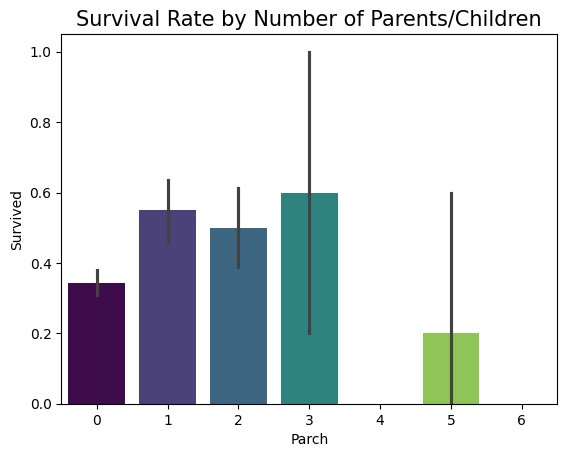

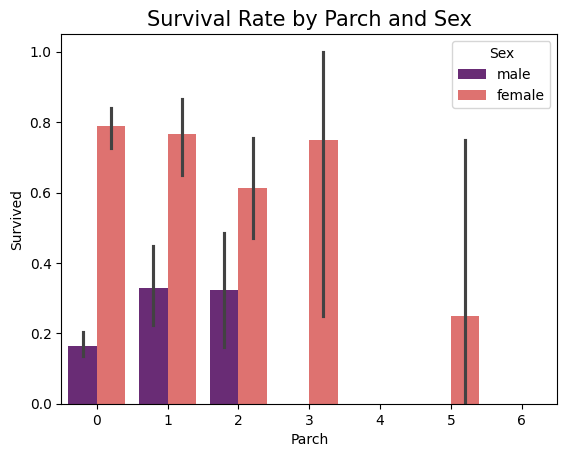

In [7]:
# Survival Rate by Parch (Parents/Children)
sns.barplot(x='Parch', y='Survived', data=train, palette='viridis', hue='Parch', legend=False)
plt.title('Survival Rate by Number of Parents/Children', fontsize=15)
plt.show()

# Survival Rate by Parch and Sex
sns.barplot(x='Parch', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by Parch and Sex', fontsize=15)
plt.show()

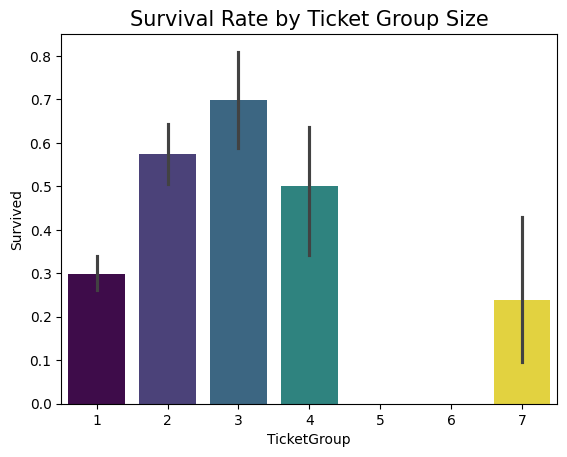

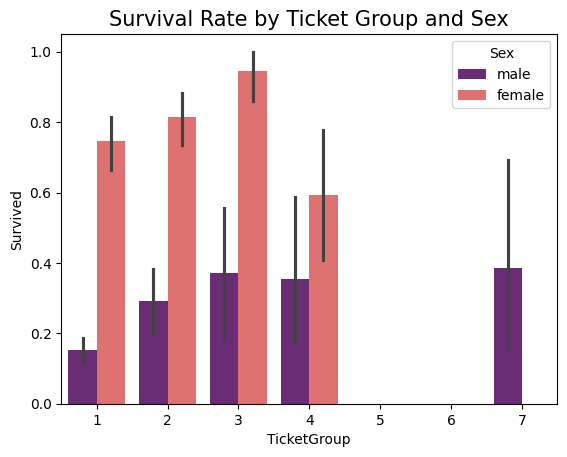

In [8]:
# 1. Calculate Group Size from Ticket
train['TicketGroup'] = train.groupby('Ticket')['Ticket'].transform('count')

# 2. Plot Survival Rate by Ticket Group Size
sns.barplot(x='TicketGroup', y='Survived', data=train, palette='viridis', hue='TicketGroup', legend=False)
plt.title('Survival Rate by Ticket Group Size', fontsize=15)
plt.show()

# 3. Plot Survival by Ticket Group and Sex
sns.barplot(x='TicketGroup', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by Ticket Group and Sex', fontsize=15)
plt.show()

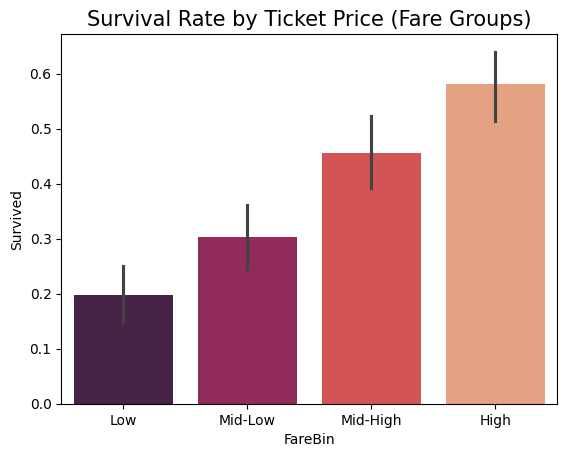

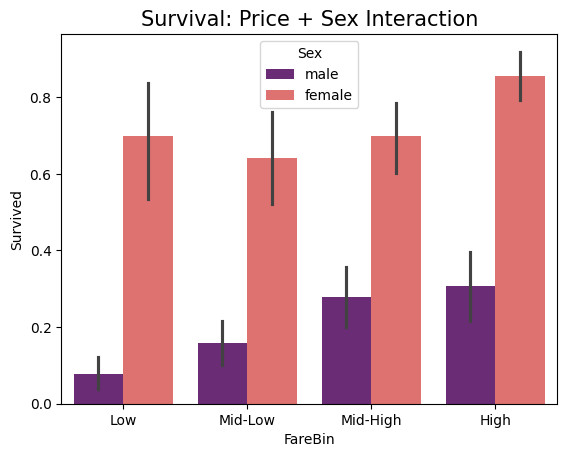

In [9]:
# 1. Create 4 "Price Buckets" (Quartiles)
train['FareBin'] = pd.qcut(train['Fare'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# 2. Plot Survival Rate by Fare Bucket
sns.barplot(x='FareBin', y='Survived', data=train, palette='rocket', hue='FareBin', legend=False)
plt.title('Survival Rate by Ticket Price (Fare Groups)', fontsize=15)
plt.show()

# 3. The "Rich Women" Insight (Fare + Sex)
sns.barplot(x='FareBin', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival: Price + Sex Interaction', fontsize=15)
plt.show()

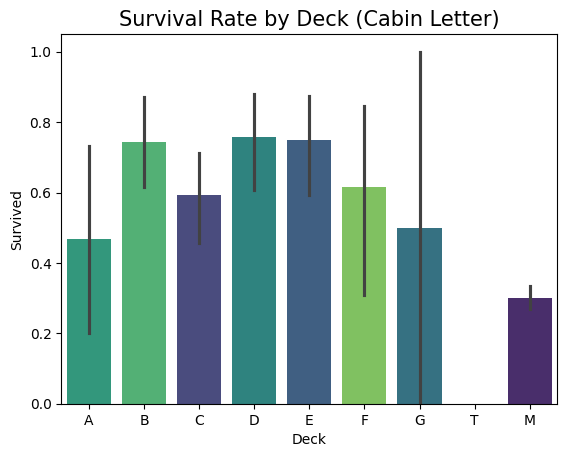

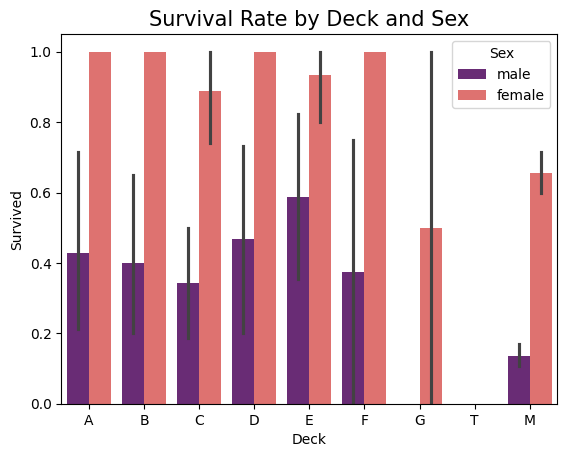

In [10]:
# 1. Extract the Deck (First letter of Cabin)
# We use 'M' for 'Missing' to handle the NaN values
train['Deck'] = train['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'M')

# 2. Plot Survival Rate by Deck
# Ordered from top of the ship (A) to bottom, with 'M' at the end
deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'M']
sns.barplot(x='Deck', y='Survived', data=train, palette='viridis', order=deck_order, hue='Deck', legend=False)
plt.title('Survival Rate by Deck (Cabin Letter)', fontsize=15)
plt.show()

# 3. Deck + Sex Interaction
sns.barplot(x='Deck', y='Survived', hue='Sex', data=train, palette='magma', order=deck_order)
plt.title('Survival Rate by Deck and Sex', fontsize=15)
plt.show()

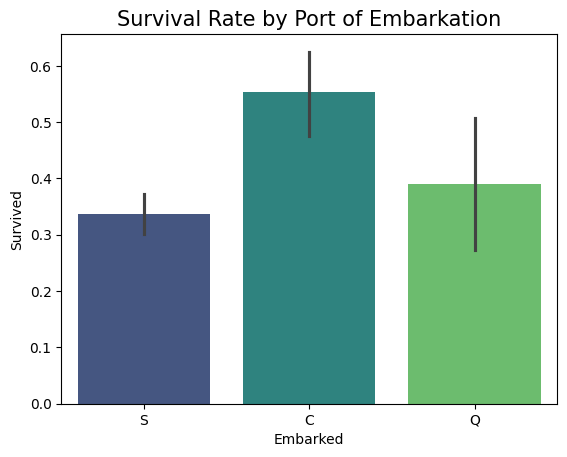

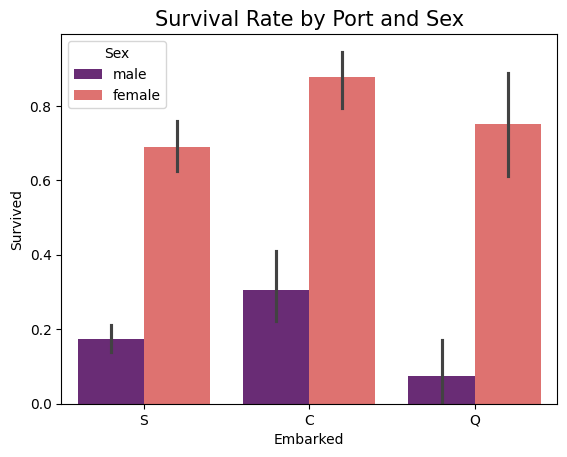

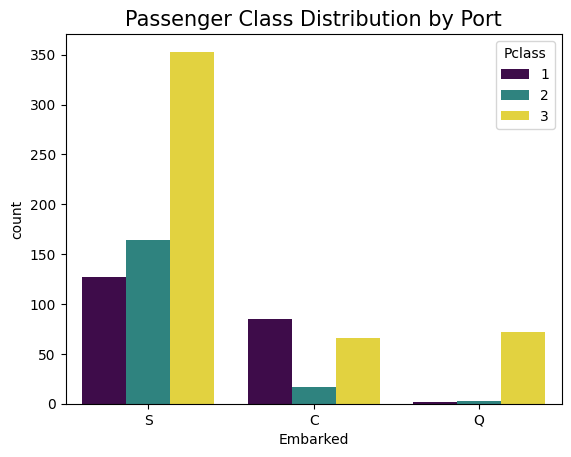

In [11]:
# 1. Plot Survival Rate by Port of Embarkation
sns.barplot(x='Embarked', y='Survived', data=train, palette='viridis', hue='Embarked', legend=False)
plt.title('Survival Rate by Port of Embarkation', fontsize=15)
plt.show()

# 2. Port + Sex Interaction
sns.barplot(x='Embarked', y='Survived', hue='Sex', data=train, palette='magma')
plt.title('Survival Rate by Port and Sex', fontsize=15)
plt.show()

# 3. Why is Cherbourg (C) higher? Let's check the Class distribution per port
sns.countplot(x='Embarked', hue='Pclass', data=train, palette='viridis')
plt.title('Passenger Class Distribution by Port', fontsize=15)
plt.show()

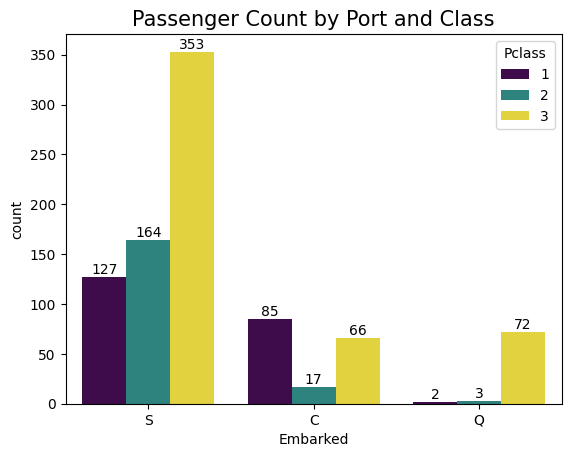

In [12]:
# 1. Create the plot
ax = sns.countplot(x='Embarked', hue='Pclass', data=train, palette='viridis')
plt.title('Passenger Count by Port and Class', fontsize=15)

# 2. Add the numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [13]:
test_ids = test["PassengerId"]

rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]

for dataset in [train, test]:
    dataset["Sex"] = dataset["Sex"].map({"male":0,"female":1})
    
    dataset["FamilySize"] = dataset["SibSp"] + dataset["Parch"] + 1
    dataset["IsAlone"] = (dataset["FamilySize"] == 1).astype(int)
    
    dataset["Embarked"] = dataset["Embarked"].fillna("S")
    dataset["Embarked"] = dataset["Embarked"].map({"S":0,"C":1,"Q":2})
    
    dataset["Title"] = dataset["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    dataset["Title"] = dataset["Title"].replace(rare_titles, "Rare")
    dataset["Title"] = dataset["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
    dataset["Title"] = dataset["Title"].map({"Mr":0,"Miss":1,"Mrs":2,"Master":3,"Rare":4})
                                             
    dataset["Fare"] = dataset["Fare"].fillna(dataset["Fare"].median())
    dataset["Fare"] = np.log1p(dataset["Fare"])
    
    dataset["Age"] = dataset.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))

    dataset["Cabin"] = dataset["Cabin"].fillna("U")
    dataset["Deck"] = dataset["Cabin"].str[0]
    dataset["Deck"] = dataset["Deck"].map({'B': 2, 'D': 2, 'E': 2, 'A': 1, 'C': 1, 'F': 1, 'G': 1, 'U': 0, 'T': 0})
    
    dataset["TicketGroup"] = dataset.groupby("Ticket")["Ticket"].transform("count")

In [14]:
features = ["Pclass","Sex", "FamilySize", "IsAlone", "Age", "Title"]
rest = ["Fare","Embarked","Title", "TicketGroup"]
X_train = train[features]
y_train = train["Survived"]
X_test = test[features]

In [15]:
def test_n_estimators(X_train, y_train, estimator_list):
    results = {}

    for n in estimator_list:
        model = RandomForestClassifier(
            n_estimators=500,
            max_depth=7,
            min_samples_split=2,
            min_samples_leaf=n,
            random_state=42
        )

        model.fit(X_train, y_train)
        score = cross_val_score(model, X_train, y_train, cv=5).mean()
        results[n] = score

    return results

In [16]:
estimators = [1,2,3,4,5,6,8,10]

#results = test_n_estimators(X_train, y_train, estimators)

#print(results)

In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8810325476992144


In [18]:
pred = model.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": pred
})
submission.to_csv("submission.csv", index=False)

In [19]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
